# Load libraries and define some functions

## Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from joblib import Parallel, delayed
from scipy.special import logsumexp
from scipy.stats import norm
from pathlib import Path
import stan
import arviz as az

import nest_asyncio
nest_asyncio.apply()

# load prepared data from data_processing.ipynb
filename = "../Data/gb_energy_data_filled.csv"
data_gb = pd.read_csv(filename)
data_gb['utc_timestamp'] = pd.to_datetime(data_gb['utc_timestamp'])
data_gb = data_gb.set_index('utc_timestamp').sort_index()
data_gb = data_gb.asfreq('h') 

data_gb['diff_price_day_ahead'] = data_gb['GB_GBN_price_day_ahead'].diff()
data_gb['diff_price_day_ahead_filled'] = data_gb['price_day_ahead_filled'].diff()

## Posterior Plotters

In [2]:
def plot_trace_and_densities(fit, param_names, num_samples, n_chains):
    total_param_number = 0
    for param in param_names:
        if param not in fit.keys():
            print(param, "not present.")
            continue
        if fit[param].ndim == 3:
            total_param_number += fit[param].shape[0] * fit[param].shape[1]
        else:
            total_param_number += fit[param].shape[0]

    fig, axes = plt.subplots(total_param_number, 2, figsize=(8, 1.5*total_param_number))
    fig_index = 0
    for param in param_names:
        if fit[param].ndim==3:
            n_row = fit[param].shape[0]
            n_col = fit[param].shape[1]
            for i in range(n_row):
                for j in range(n_col):
                    param_name =  param + "[" + str(i) + ", " + str(j) +"]"
                    posterior_draws = fit[param][i,j].reshape(num_samples, n_chains).T

                    for chain_index in range(n_chains):
                        axes[fig_index, 0].plot(posterior_draws[chain_index], alpha=0.7)
                        axes[fig_index, 1].hist(posterior_draws[chain_index], 100, alpha=0.7)
                    axes[fig_index, 0].set_title(param_name)
                    axes[fig_index, 1].set_title(param_name)
                    fig_index += 1

        elif fit[param].ndim==2:
            if fit[param].shape[0]>1:
                n_param = fit[param].shape[0]
                for param_index in range(n_param):
                    param_name = param+'[' + str(param_index) +']'
                    posterior_draws = fit[param][param_index].reshape(num_samples, n_chains).T
                    for chain_index in range(n_chains):
                        axes[fig_index, 0].plot(posterior_draws[chain_index], alpha=0.7)
                        axes[fig_index, 1].hist(posterior_draws[chain_index], 100, alpha=0.7)

                    axes[fig_index, 0].set_title(param_name)
                    axes[fig_index, 1].set_title(param_name)
                    fig_index += 1
            else:
                posterior_draws = fit[param][0].reshape(num_samples, n_chains).T
                for chain_index in range(n_chains):
                    axes[fig_index, 0].plot(posterior_draws[chain_index], alpha=0.7)
                    axes[fig_index, 1].hist(posterior_draws[chain_index], 100, alpha=0.7)
                axes[fig_index, 0].set_title(param)
                axes[fig_index, 1].set_title(param)
                fig_index += 1
    plt.tight_layout()
    plt.show()


def plot_posterior_scatter_matrix(fit, param_names, num_samples, n_chains, max_points=2000):
    posterior_draws = {}
    for param in param_names:
        if param not in fit.keys():
            print(f"Parameter {param} missing from fit.")
            continue
        arr = fit[param]
        if arr.ndim == 1:
            posterior_draws[param] = arr.reshape(num_samples, n_chains).T.flatten()
        else:
            for k in range(arr.shape[0]):
                posterior_draws[f"{param}[{k+1}]"] = arr[k].reshape(num_samples, n_chains).T.flatten()

    keys = list(posterior_draws.keys())
    if len(keys) == 0:
        return

    total_points = len(next(iter(posterior_draws.values())))
    sample_idx = np.random.choice(total_points, min(total_points, max_points), replace=False)

    n = len(keys)
    fig, axes = plt.subplots(n, n, figsize=(3*n, 3*n))
    for i, xi in enumerate(keys):
        for j, yj in enumerate(keys):
            ax = axes[i, j]
            if i == j:
                ax.hist(posterior_draws[xi][sample_idx], bins=30, color='lightblue')
            else:
                ax.scatter(posterior_draws[yj][sample_idx],
                           posterior_draws[xi][sample_idx],
                           s=3, alpha=0.4)
            if i == n - 1:
                ax.set_xlabel(yj)
            else:
                ax.set_xticklabels([])
            if j == 0:
                ax.set_ylabel(xi)
            else:
                ax.set_yticklabels([])

    fig.suptitle("Posterior draw scatter matrix")
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

## Posteior Predictive Sampling Functions

In [2]:
def mean_function(parameter_values: pd.Series, X_data: pd.DataFrame):
    day_coef_index = [i for i in range(parameter_values.shape[0]) if 'day_coef' in parameter_values.keys()[i]]
    hour_coef_index = [i for i in range(parameter_values.shape[0]) if 'hour_coef' in parameter_values.keys()[i]]

    day_coef_vals = np.insert(parameter_values.iloc[day_coef_index].to_numpy(), 0, 0.0)
    hour_coef_vals = np.insert(parameter_values.iloc[hour_coef_index].to_numpy(), 0 , 0.0)

    # f_1
    # mean = parameter_values['overall_mean'] + parameter_values['yearly_trend'] * X_data['time_year'] + hour_coef_vals[X_data['hour_indicator']] + day_coef_vals[X_data['day_indicator']]
    # f_2
    # mean = parameter_values['overall_mean'] + parameter_values['yearly_trend'] * X_data['time_year'] + hour_coef_vals[X_data['hour_indicator']] + day_coef_vals[X_data['day_indicator']] + parameter_values['fourier_coef.1'] * np.cos(2*np.pi*X_data['time_year']) + parameter_values['fourier_coef.2'] * np.sin(2*np.pi*X_data['time_year'])
    # f_3
    mean = parameter_values['overall_mean'] + parameter_values['yearly_trend'] * X_data['time_year'] + hour_coef_vals[X_data['hour_indicator']] + day_coef_vals[X_data['day_indicator']] 
    for k in range(1,4):
        a1 = parameter_values['fourier_coef.1.' + str(k)]
        a2 = parameter_values['fourier_coef.2.' + str(k)]
        mean += +  a1* np.cos(2*np.pi*k*X_data['time_year']) + a2 * np.sin(2*np.pi*k*X_data['time_year'])
    return mean.to_numpy()

def mean_function_yearly_trend(parameter_values: pd.Series, X_data: pd.DataFrame):
    day_coef_index = [i for i in range(parameter_values.shape[0]) if 'day_coef' in parameter_values.keys()[i]]
    hour_coef_index = [i for i in range(parameter_values.shape[0]) if 'hour_coef' in parameter_values.keys()[i]]

    day_coef_vals = np.insert(parameter_values.iloc[day_coef_index].to_numpy(), 0, 0.0)
    hour_coef_vals = np.insert(parameter_values.iloc[hour_coef_index].to_numpy(), 0 , 0.0)

    # f_1
    # mean = parameter_values['overall_mean'] + parameter_values['yearly_trend'] * X_data['time_year'] + hour_coef_vals[X_data['hour_indicator']] + day_coef_vals[X_data['day_indicator']]
    # f_2
    # mean = parameter_values['overall_mean'] + parameter_values['yearly_trend'] * X_data['time_year'] + hour_coef_vals[X_data['hour_indicator']] + day_coef_vals[X_data['day_indicator']] + parameter_values['fourier_coef.1'] * np.cos(2*np.pi*X_data['time_year']) + parameter_values['fourier_coef.2'] * np.sin(2*np.pi*X_data['time_year'])
    # f_3
    mean = parameter_values['overall_mean'] + parameter_values['yearly_trend'] * X_data['time_year']
    for k in range(1,4):
        a1 = parameter_values['fourier_coef.1.' + str(k)]
        a2 = parameter_values['fourier_coef.2.' + str(k)]
        mean += +  a1* np.cos(2*np.pi*k*X_data['time_year']) + a2 * np.sin(2*np.pi*k*X_data['time_year'])
    return mean.to_numpy()

def posterior_mean_function_yearly_trend(post: pd.DataFrame, X_data: pd.DataFrame):
    n_post = post.shape[0]
    n_data = X_data.shape[0]

    post_mean_fn = np.empty((n_post, n_data))
    for post_ind in range(n_post):
        param_vals = post.iloc[post_ind, ]
        post_mean_fn[post_ind,] = mean_function_yearly_trend(param_vals, X_data)

    return post_mean_fn


def sample_mf_ou_process(parameter_values: pd.Series, initial_value: float, X_data: pd.DataFrame, dt=1):
    n_steps = X_data.shape[0]
    alpha = np.exp(-parameter_values['theta'] * dt)

    det_mean = mean_function(parameter_values, X_data)

    output = [None] * n_steps
    output[0] = initial_value
    OU_step_sd = parameter_values['sigma'] * np.sqrt( (1 - alpha*alpha) / (2*parameter_values['theta']))
    random_steps = OU_step_sd * np.random.normal(size=n_steps) 
    for t in range(1, n_steps):
        output[t] = det_mean[t] + alpha * (output[t-1] - det_mean[t-1]) + random_steps[t]
    return output

def one_step_ahead_prediction(post: pd.DataFrame, y_data: np.array, X_data: pd.DataFrame):
    n_post = post.shape[0]
    n_data = len(y_data)
    output = np.empty((n_post, n_data))
    for post_ind in range(n_post):
        param_vals = post.iloc[post_ind,:]
        alpha = np.exp(-param_vals['theta'])
        det_mean = mean_function(param_vals, X_data)
        out = np.empty(n_data)

        m = det_mean[1:] + alpha * (y_data[:-1] - det_mean[:-1]) 

        sd = param_vals['sigma'] * np.sqrt( (1 - alpha*alpha) / (2*param_vals['theta']) )
        out[0] = y_data[0]

        out[1:] = m + sd * np.random.normal(size=(n_data-1))
        output[post_ind,] = out
    return output

def sample_posterior_predicitive(post: pd.DataFrame, y_initial_value: float, X_data: pd.DataFrame):
    n_post = post.shape[0]
    output = [None] * n_post
    for post_ind in range(n_post):
        param_vals = post.iloc[post_ind,:]
        output[post_ind] = sample_mf_ou_process(param_vals,  
                                                y_initial_value, 
                                                X_data)
    return output

def posterior_one_step_ahead_expectation(post: pd.DataFrame, y_data: np.array, X_data: pd.DataFrame):
    n_post = post.shape[0]
    n_data = y_data.shape[0]
    output = np.empty((n_post, n_data))

    for post_ind in range(n_post):
        param_vals = post.iloc[post_ind, :]
        alpha = np.exp(-param_vals['theta'])
        det_mean = mean_function(param_vals, X_data)
        out = np.empty(len(y_data))
        out[0] = y_data[0]
        out[1:] = det_mean[1:] + alpha * (y_data[:-1] - det_mean[:-1])
        output[post_ind, ] = out
        
    return output


## Dataset Setup

In [4]:
training_window_size = 2*365 

final_month = data_gb.index.max().to_period("M")
validation_data = data_gb[data_gb.index.to_period("M") == final_month]
validation_data_start_date = min(validation_data.index)
validation_data_end_date = max(validation_data.index)
validation_data_days = np.unique(validation_data.index.to_period("D"))

training_window_start_date = validation_data_start_date - pd.Timedelta(days=training_window_size)
training_data = data_gb[(data_gb.index>=training_window_start_date) &
                        (data_gb.index<validation_data_start_date)]

print("Validation data time limits: " + str(validation_data_start_date) + ", " + str(validation_data_end_date))

Validation data time limits: 2020-09-01 00:00:00+00:00, 2020-09-30 23:00:00+00:00


/var/folders/xd/cr1ckt0968vbzs7sbhxy85w40000gq/T/ipykernel_3669/3974001527.py:3: UserWarning: Converting to Period representation will drop timezone information.
  final_month = data_gb.index.max().to_period("M")
/var/folders/xd/cr1ckt0968vbzs7sbhxy85w40000gq/T/ipykernel_3669/3974001527.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  validation_data = data_gb[data_gb.index.to_period("M") == final_month]
/var/folders/xd/cr1ckt0968vbzs7sbhxy85w40000gq/T/ipykernel_3669/3974001527.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  validation_data_days = np.unique(validation_data.index.to_period("D"))


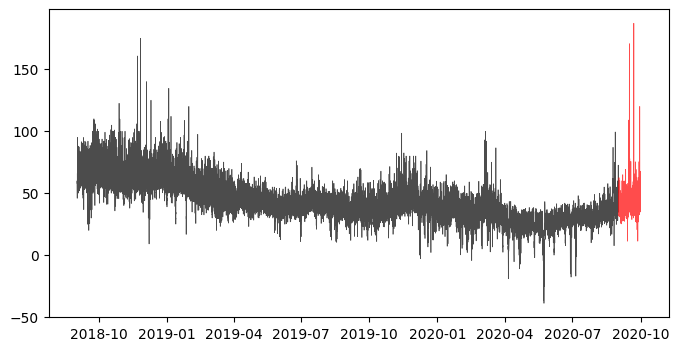

In [5]:
fig, axes = plt.subplots(1, figsize=(8, 4))

axes.plot(training_data.index, 
         training_data['price_day_ahead_filled'], 
         linewidth=0.5, alpha=0.7, color='black')
axes.plot(validation_data.index, 
         validation_data['price_day_ahead_filled'], 
         linewidth=0.5, alpha=0.7, color='red')

In [7]:
# Stan is 1-indexed, so add 1
month_idx  = (training_data.index.month).to_numpy(dtype=int)   # 1–12
day_idx   = (training_data.index.day_of_week + 1).to_numpy(dtype=int)  # 1–7
hour_idx  = (training_data.index.hour + 1).to_numpy(dtype=int)   # 1–24

month_idx_fore  = (validation_data.index.month).to_numpy(dtype=int)   # 1–12
day_idx_fore = (validation_data.index.day_of_week + 1).to_numpy(dtype=int)  # 1–7
hour_idx_fore = (validation_data.index.hour + 1).to_numpy(dtype=int)   # 1–24

time_year_obs_data = np.arange(0, training_data.shape[0]) / 8760
time_year_val_data = np.arange(training_data.shape[0], training_data.shape[0] + validation_data.shape[0]) / 8760

stan_training_X_data = pd.DataFrame({
    'time_year': time_year_obs_data,
    'month_indicator': month_idx,
    'hour_indicator': hour_idx,
    'day_indicator': day_idx
    })

stan_validation_X_data = pd.DataFrame({
    'time_year': time_year_val_data,
    'month_indicator': month_idx_fore,
    'hour_indicator': hour_idx_fore,
    'day_indicator': day_idx_fore
})

# Fit model

## Infer Parameters

In [ ]:
stan_data = {
    # -- training data
    'T': len(training_data['price_day_ahead_filled']),
    'y': training_data['price_day_ahead_filled'].to_numpy(),
    'time_year': stan_training_X_data['time_year'].to_numpy(),
    'month_index': stan_training_X_data['month_indicator'].to_numpy(),
    'day_of_week_index': stan_training_X_data['day_indicator'].to_numpy(),
    'hour_index': stan_training_X_data['hour_indicator'].to_numpy(),
    'dt': 1,

    # -- validation data

    # -- prior parameters
    'theta_mean': 2,
    'theta_sd': 1,

    'sigma_shape': 3 ** 2 / 1.0,
    'sigma_rate': 3 / 1.0,

    'overall_mean_mu': np.mean(training_data['price_day_ahead_filled']),
    'overall_mean_sd': 1
}

In [3]:
stan_model_file = Path('./stan_files/ou.stan')
model_code = stan_model_file.read_text()
posterior = stan.build(model_code, data=stan_data)

n_chains = 4
n_burnin = 500
n_posterior = 1000

fit = posterior.sample(num_chains=n_chains, num_samples=n_posterior, num_warmup=n_burnin)

NameError: name 'stan_data' is not defined

## Plot Posterior Chains

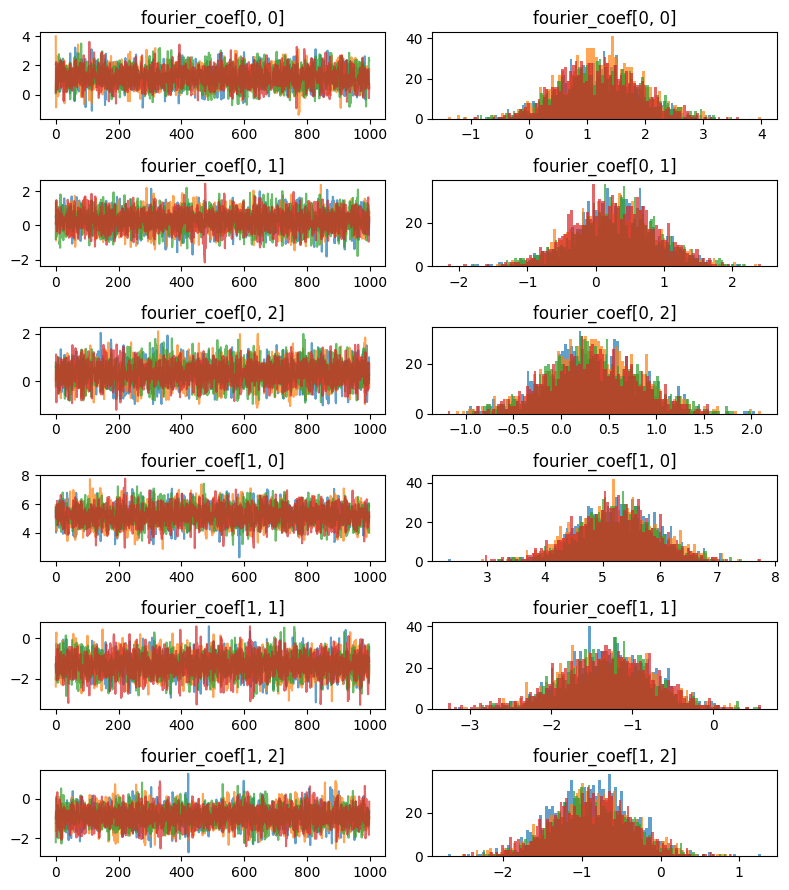

In [28]:
plot_trace_and_densities(fit, ['fourier_coef'], n_posterior, n_chains)

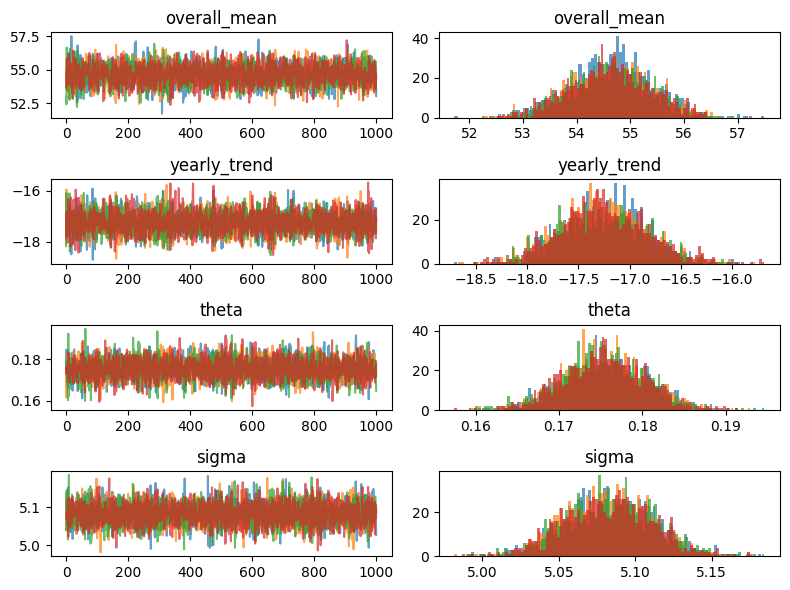

In [29]:
plot_trace_and_densities(fit, ['overall_mean', 'yearly_trend', 'theta', 'sigma'], n_posterior, n_chains)

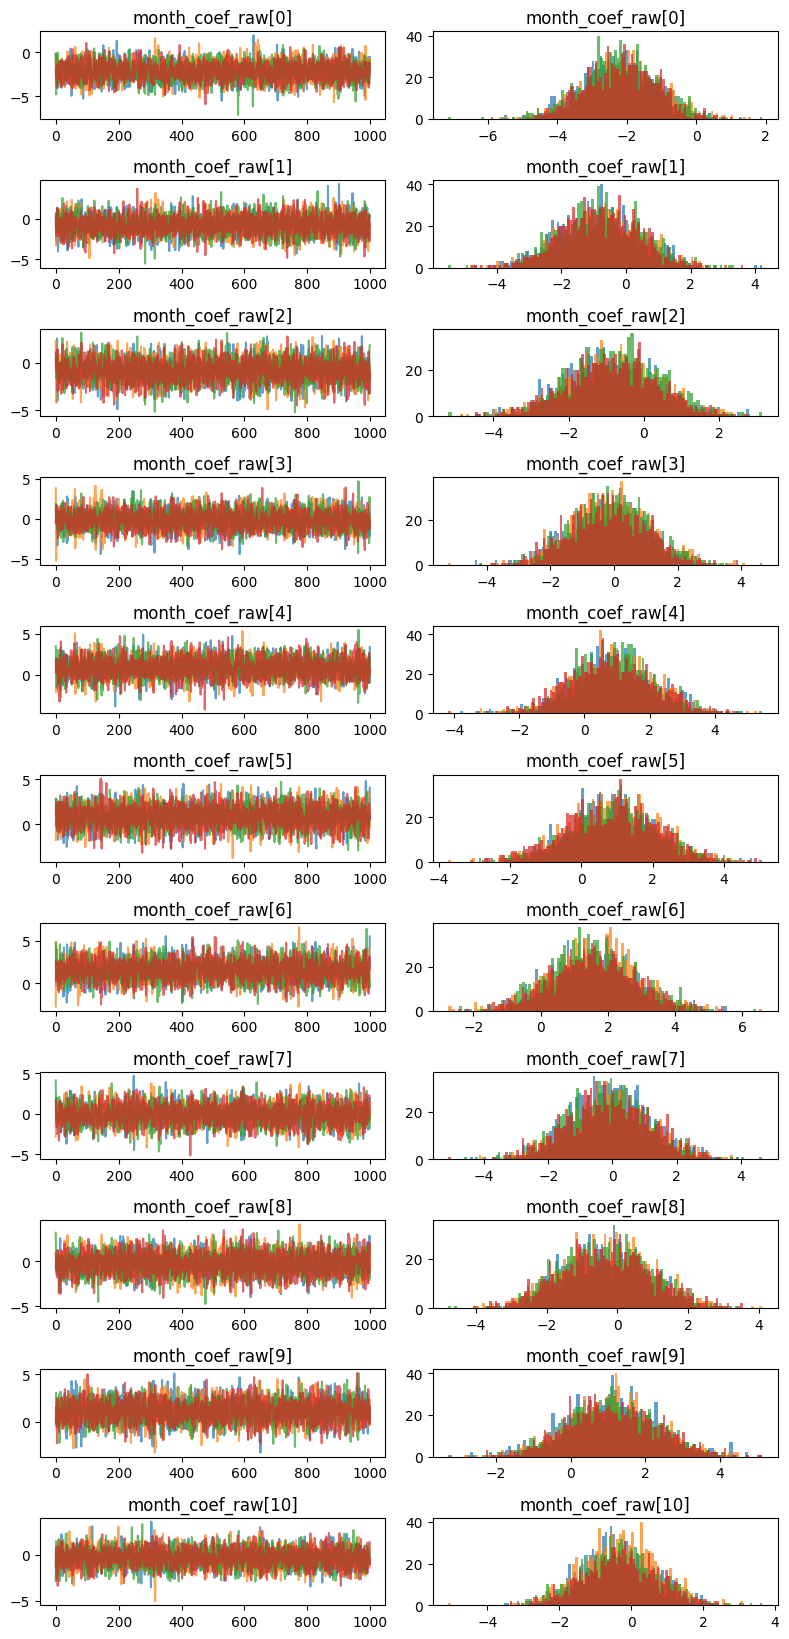

In [30]:
plot_trace_and_densities(fit, ['month_coef_raw'], n_posterior, n_chains) 

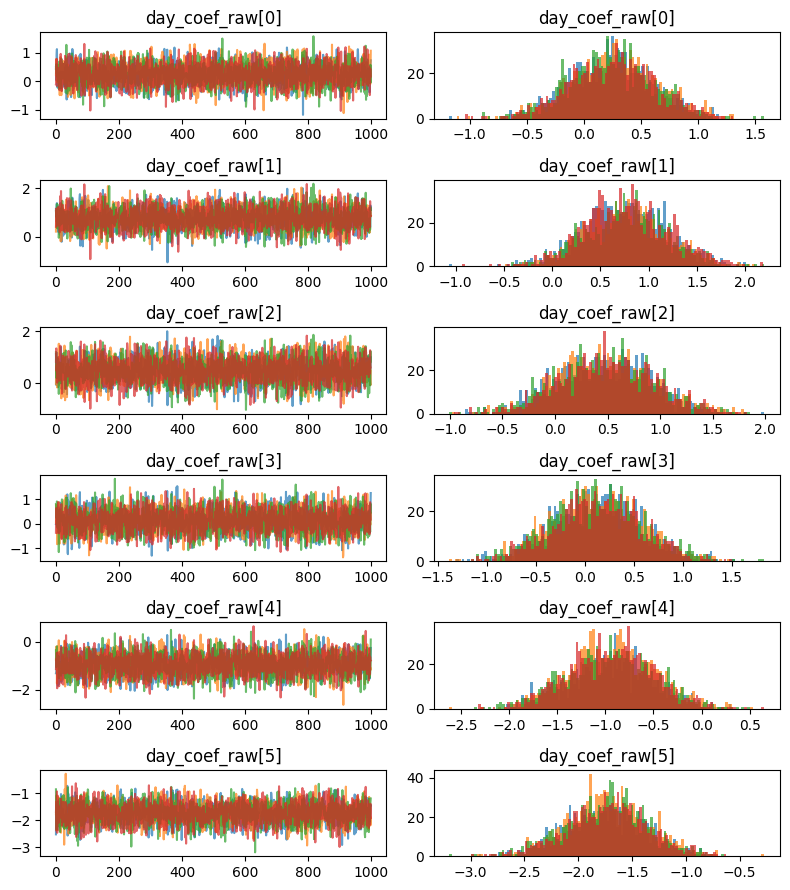

In [31]:
plot_trace_and_densities(fit, ['day_coef_raw'], n_posterior, n_chains) 

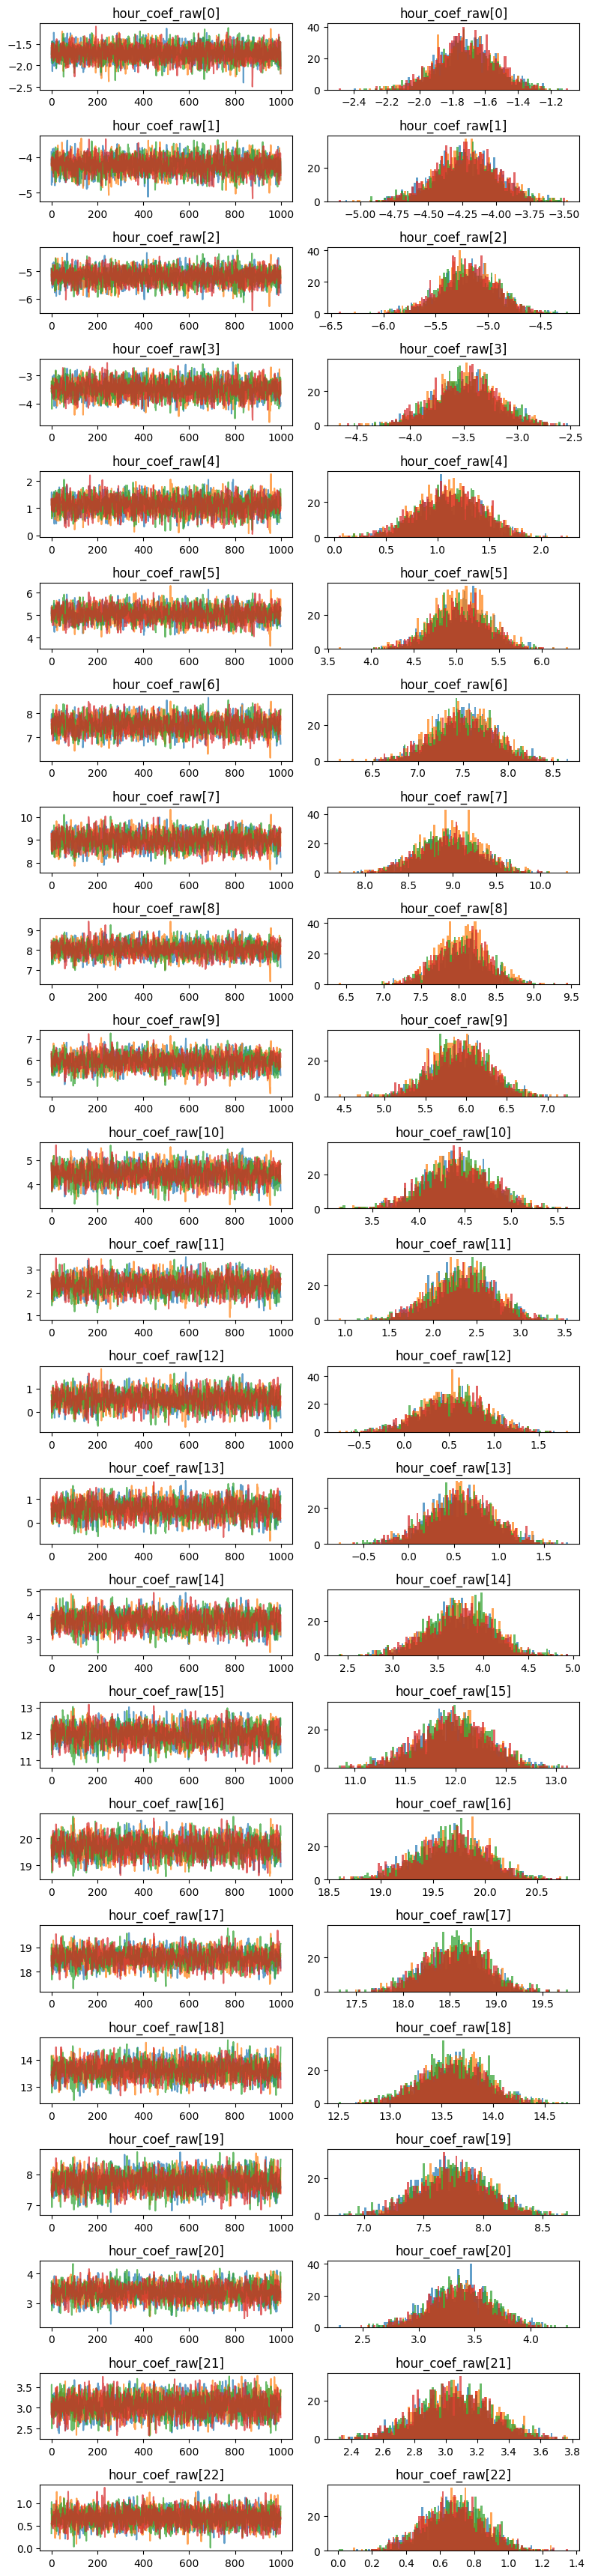

In [32]:
plot_trace_and_densities(fit, ['hour_coef_raw'], n_posterior, n_chains)

## Save Posterior Output

In [ ]:
# Save the posterior parameter draws
save_output = False

if save_output:
    fit_df = fit.to_frame()

    param_names = ['lp__', 'overall_mean', 'yearly_trend', 'theta', 'sigma']
    for i in range(1,7):
        param_names.append("day_coef_raw." + str(i))
    for i in range(1,24):
        param_names.append("hour_coef_raw." + str(i))
    for i in range(1,3):
        for j in range(1,4):
            param_names.append("fourier_coef." + str(i) + "." + str(j))
        
    print(param_names)
    post_to_save = fit_df[param_names]
    post_to_save.to_csv("./Posterior/ou_parameters.csv")

['lp__', 'overall_mean', 'yearly_trend', 'theta', 'sigma', 'day_coef_raw.1', 'day_coef_raw.2', 'day_coef_raw.3', 'day_coef_raw.4', 'day_coef_raw.5', 'day_coef_raw.6', 'hour_coef_raw.1', 'hour_coef_raw.2', 'hour_coef_raw.3', 'hour_coef_raw.4', 'hour_coef_raw.5', 'hour_coef_raw.6', 'hour_coef_raw.7', 'hour_coef_raw.8', 'hour_coef_raw.9', 'hour_coef_raw.10', 'hour_coef_raw.11', 'hour_coef_raw.12', 'hour_coef_raw.13', 'hour_coef_raw.14', 'hour_coef_raw.15', 'hour_coef_raw.16', 'hour_coef_raw.17', 'hour_coef_raw.18', 'hour_coef_raw.19', 'hour_coef_raw.20', 'hour_coef_raw.21', 'hour_coef_raw.22', 'hour_coef_raw.23', 'fourier_coef.1.1', 'fourier_coef.1.2', 'fourier_coef.1.3', 'fourier_coef.2.1', 'fourier_coef.2.2', 'fourier_coef.2.3']


# Posterior Predictive Samples

In [8]:
# Include the final observation of the training data in the validation data, so that it can be conditioned upon
day_idx   = (training_data.index.day_of_week).to_numpy(dtype=int)  # 0-6
hour_idx  = (training_data.index.hour ).to_numpy(dtype=int)   # 0-23

day_idx_fore = (validation_data.index.day_of_week).to_numpy(dtype=int)  # 0-6
hour_idx_fore = (validation_data.index.hour).to_numpy(dtype=int)   # 0-23

day_idx_fore = np.insert(day_idx_fore, 0, day_idx[-1])
hour_idx_fore = np.insert(hour_idx_fore, 0, hour_idx[-1])

time_year_obs_data = np.arange(0, training_data.shape[0]) / 8760
time_year_val_data = np.arange(training_data.shape[0]-1, training_data.shape[0] + validation_data.shape[0]) / 8760

training_X_data = pd.DataFrame({
    'time_year': time_year_obs_data,
    'hour_indicator': hour_idx,
    'day_indicator': day_idx
    })

validation_X_data = pd.DataFrame({
    'time': pd.date_range(training_data.index[-1], validation_data.index[-1], freq="h"),
    'price_day_ahead_filled': np.insert(validation_data['price_day_ahead_filled'].to_numpy(), 0, training_data['price_day_ahead_filled'].iloc[-1]),
    'time_year': time_year_val_data,
    'hour_indicator': hour_idx_fore,
    'day_indicator': day_idx_fore
})

filename = "./posterior_files/levels_mf3_ou_parameters.csv"
post_df = pd.read_csv(filename)


## Mean Function and Expectation

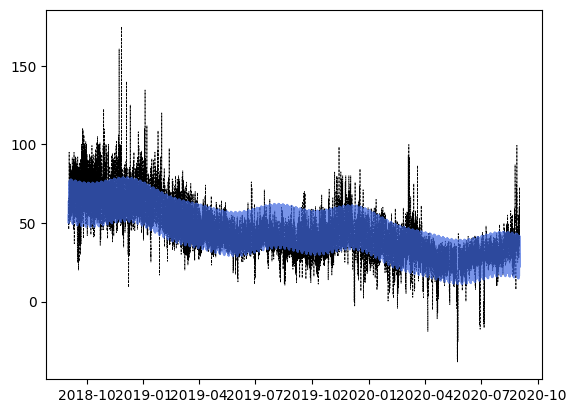

In [30]:
mm = mean_function(post_df.iloc[100,:], training_X_data)

plt.plot(training_data.index, 
         training_data['GB_GBN_price_day_ahead'], 
         linestyle='--', linewidth=0.5, color='black')
plt.plot(training_data.index, mean_function(post_df.iloc[0,:], training_X_data),
         color='royalblue', alpha=0.7)


(np.float64(18476.0), np.float64(18505.958333333332))

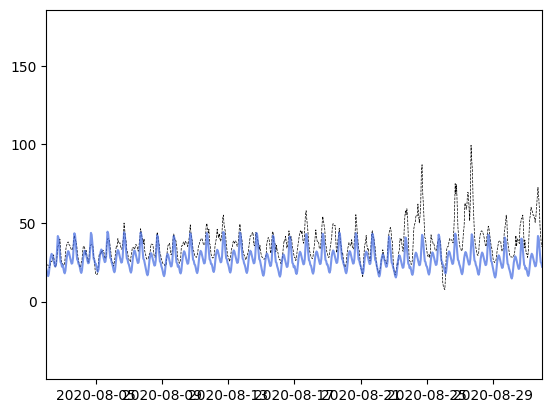

In [31]:
plt.plot(training_data.index, 
         training_data['GB_GBN_price_day_ahead'], 
         linestyle='--', linewidth=0.5, color='black')
plt.plot(training_data.index, mean_function(post_df.iloc[0,:], training_X_data),
         color='royalblue', alpha=0.7)
plt.xlim([training_data.index[-30*24], training_data.index[-1]])

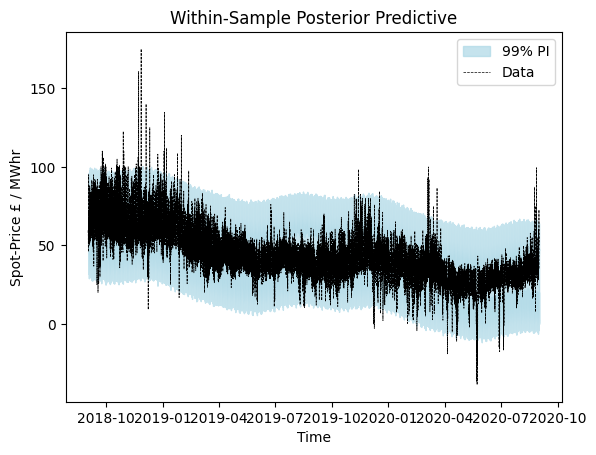

In [85]:
post_pred = sample_posterior_predicitive(post_df, training_data['GB_GBN_price_day_ahead'].iloc[0], training_X_data)
post_pred_qnts = np.quantile(post_pred, [0.005, 0.995], axis=0)

plt.fill_between(training_data.index, 
                 post_pred_qnts[0], 
                 post_pred_qnts[1], 
                 color='lightblue', alpha=0.7, label="99% PI")
plt.plot(training_data.index, training_data['GB_GBN_price_day_ahead'], 
         linestyle='--', color='black', linewidth=0.5, label="Data")
plt.title("Within-Sample Posterior Predictive")
plt.ylabel("Spot-Price £ / MWhr")
plt.xlabel("Time")
plt.legend()

Text(0.5, 0, 'Time')

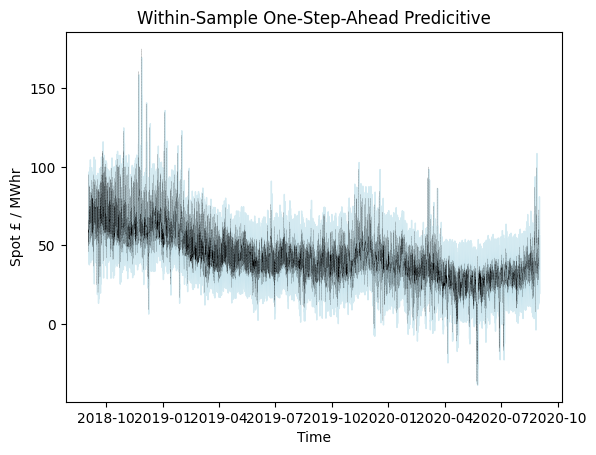

In [99]:
one_step_pred = one_step_ahead_prediction(post_df, training_data['price_day_ahead_filled'].to_numpy(), training_X_data)
one_step_pred_qnts = np.quantile(one_step_pred, [0.005, 0.25, 0.75, 0.995], axis=0)

plt.fill_between(training_data.index, 
                 one_step_pred_qnts[0], 
                 one_step_pred_qnts[3], 
                 color='lightblue', alpha=0.5, label="99% PI")
plt.plot(training_data.index,
         training_data['GB_GBN_price_day_ahead'], 
         linestyle='--', color='black', linewidth=0.1, label="Data")
plt.title("Within-Sample One-Step-Ahead Predicitive")
plt.ylabel("Spot £ / MWhr")
plt.xlabel("Time")

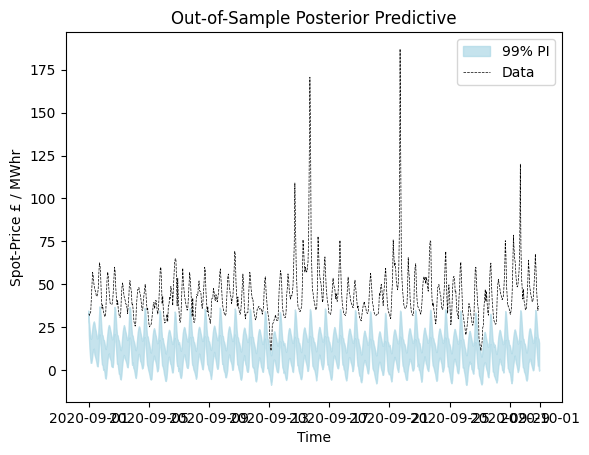

In [106]:
post_pred_validation = sample_posterior_predicitive(post_df, validation_X_data['price_day_ahead_filled'].iloc[0], validation_X_data)
pred_forecast_qnts = np.quantile(post_pred_validation, [0.005, 0.25, 0.75, 0.995], axis=0)

plt.fill_between(validation_X_data['time'], 
                 pred_forecast_qnts[0], 
                 pred_forecast_qnts[1], 
                 color='lightblue', alpha=0.7, label="99% PI")
plt.plot(validation_data.index, validation_data['GB_GBN_price_day_ahead'], 
         linestyle='--', color='black', linewidth=0.5, label="Data")
plt.title("Out-of-Sample Posterior Predictive")
plt.ylabel("Spot-Price £ / MWhr")
plt.xlabel("Time")
plt.legend()

## Predictive Sampling

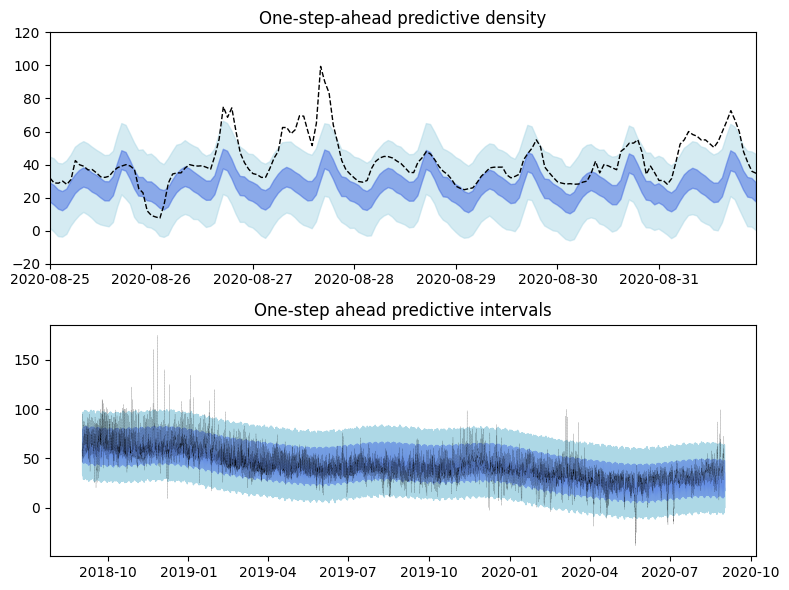

In [47]:

y_pred_qnts = np.quantile(post_pred, [0.005, 0.25, 0.75, 0.995], axis=0)

fig, axes = plt.subplots(2,1, figsize=(8,6), sharex=False)

axes[0].fill_between(training_data.index, 
                y_pred_qnts[0], 
                y_pred_qnts[3], 
                alpha=0.5, color='lightblue')
axes[0].fill_between(training_data.index, 
                y_pred_qnts[1], 
                y_pred_qnts[2], 
                alpha=0.5, color='royalblue')
axes[0].plot(training_data.index, training_data['price_day_ahead_filled'], 
             color='black', linewidth=1.0, linestyle='--', alpha=1.0)
axes[0].set_xlim([training_data.index[-7*24], training_data.index[-1]])
axes[0].set_ylim([-20,120])
axes[0].set_title("One-step-ahead predictive density")

axes[1].fill_between(training_data.index, 
                y_pred_qnts[0], 
                y_pred_qnts[3], 
                alpha=1.0, color='lightblue')
axes[1].fill_between(training_data.index, 
                y_pred_qnts[1], 
                y_pred_qnts[2], 
                alpha=0.5, color='royalblue')
axes[1].plot(training_data.index, training_data['price_day_ahead_filled'], 
             color='black', linewidth=0.1, linestyle='--', alpha=1.0)
axes[1].set_title("One-step ahead predictive intervals")

plt.tight_layout()
plt.show()


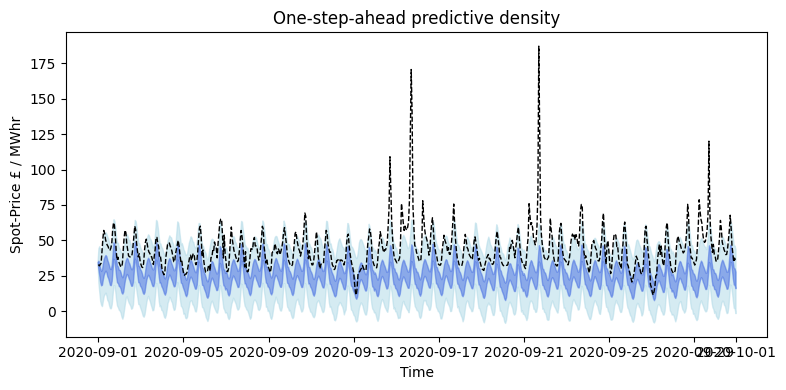

In [51]:
y_fore = post_pred_validation
y_forecast_qnts = np.quantile(y_fore, [0.005, 0.25, 0.75, 0.995], axis=0)

fig, axes = plt.subplots(1, figsize=(8,4), sharex=False)

axes.fill_between(validation_X_data['time'], 
                y_forecast_qnts[0], 
                y_forecast_qnts[3], 
                alpha=0.5, color='lightblue')
axes.fill_between(validation_X_data['time'], 
                y_forecast_qnts[1], 
                y_forecast_qnts[2], 
                alpha=0.5, color='royalblue')
axes.plot(validation_data.index, validation_data['price_day_ahead_filled'], 
             color='black', linewidth=1.0, linestyle='--', alpha=1.0)
axes.set_title("One-step-ahead predictive density")
axes.set_ylabel("Spot-Price £ / MWhr")
axes.set_xlabel("Time")
plt.tight_layout()
plt.show()


## Predictive Model Error

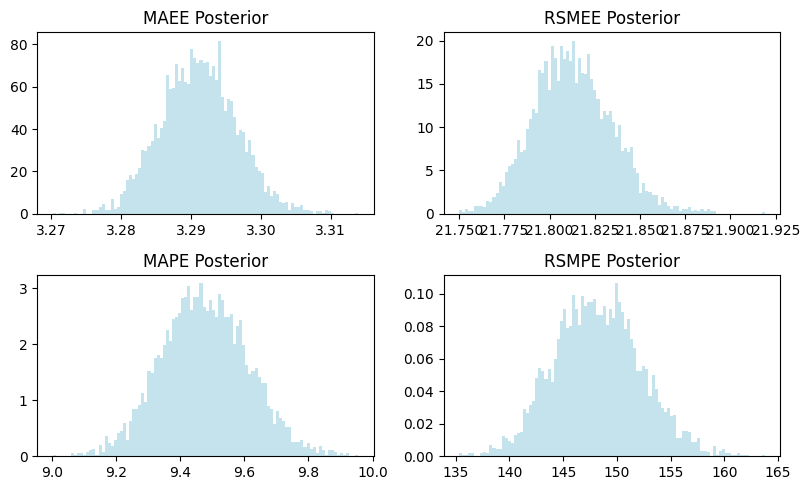

In [103]:
posterior_y_pred = sample_posterior_predicitive(post_df, training_data['GB_GBN_price_day_ahead'].iloc[0], training_X_data)
posterior_y_expected = posterior_one_step_ahead_expectation(post_df, training_data['price_day_ahead_filled'].to_numpy(), training_X_data)

posterior_maee = [None]*len(posterior_y_expected)
posterior_rmsee = [None]*len(posterior_y_expected)
posterior_mape = [None]*len(posterior_y_pred)
posterior_rmspe = [None]*len(posterior_y_pred)


for ind in range(len(posterior_y_expected)):
    maee = np.mean(abs(posterior_y_expected[ind] - training_data['GB_GBN_price_day_ahead']))
    posterior_maee[ind] = maee
    rmsee = np.mean( (posterior_y_expected[ind] - training_data['GB_GBN_price_day_ahead'])**2)
    posterior_rmsee[ind] = rmsee

for ind in range(len(posterior_y_pred)):
    mape = np.mean(abs(posterior_y_pred[ind] - training_data['GB_GBN_price_day_ahead']))
    posterior_mape[ind] = mape
    rmspe = np.mean( (posterior_y_pred[ind] - training_data['GB_GBN_price_day_ahead'])**2)
    posterior_rmspe[ind] = rmspe

fig, axes = plt.subplots(2,2, figsize=(8, 5))

axes[0,0].hist(posterior_maee, 100, density=True, 
               alpha=0.7, color='lightblue')
axes[0,0].set_title("MAEE Posterior")
axes[0,1].hist(posterior_rmsee, bins=100, density=True, 
               alpha=0.7, color='lightblue')
axes[0,1].set_title("RSMEE Posterior")

axes[1,0].hist(posterior_mape, 100, density=True, 
               alpha=0.7, color='lightblue')
axes[1,0].set_title("MAPE Posterior")
axes[1,1].hist(posterior_rmspe, bins=100, density=True, 
               alpha=0.7, color='lightblue')
axes[1,1].set_title("RSMPE Posterior")

plt.tight_layout()
plt.show()


# Model Statisticfit and Predictive Statistic

In [53]:
def posterior_loglik(post: pd.DataFrame, y_data: np.array, X_data: pd.DataFrame, predictive=False):
    n_data = X_data.shape[0]
    n_post = post.shape[0]

    ll_mat = np.empty((n_post, n_data-1))

    for post_ind in range(n_post):
        param_vals = post.iloc[post_ind, :]
        alpha = np.exp(-param_vals['theta'])
        
        det_mean = mean_function(param_vals, X_data)
        
        if predictive:
            pred_sample = sample_mf_ou_process(param_vals, y_data[0], X_data)
            mean = det_mean[1:] + alpha * (pred_sample[:(n_data-1)] - det_mean[:(n_data-1)])
        else:
            mean = det_mean[1:] + alpha * (y_data[:(n_data-1)] - det_mean[:(n_data-1)])
        
        sd = param_vals['sigma'] * np.sqrt( (1 - alpha*alpha) / (2*param_vals['theta']) )

        log_dens = norm.logpdf(y_data[1:], loc=mean, scale=sd)

        ll_mat[post_ind, :] = log_dens

    return ll_mat

def log_predictive_score_from_loglik(loglik_mat: np.array):
    n_post = loglik_mat.shape[0]

    return logsumexp(loglik_mat, axis=0) - np.log(n_post)

def log_predictive_score(post: pd.DataFrame, y_data: np.array, X_data: pd.DataFrame):
    n_post = post.shape[0]

    ll_mat = posterior_loglik(post, y_data, X_data, predictive=True)
    
    return logsumexp(ll_mat, axis=0) - np.log(n_post)
        

def waic_from_loglik(log_lik_matrix: np.array):  
    n_post = log_lik_matrix.shape[0]
    # sum of the logged mean likelihood (expected density) per observation
    log_expected_ll = logsumexp(log_lik_matrix, axis=0) - np.log(n_post) 
    mean_log_expected_ll = log_expected_ll.sum()

    # variance of log-likliehood per observation
    var_ll = np.var(log_lik_matrix, axis=0, ddof=1) 

    p_waic = 2 * (var_ll - log_expected_ll).sum()

    return p_waic

def waic(post: pd.DataFrame, y_data: np.array, X_data: pd.DataFrame):
    n_data = X_data.shape[0]
    n_post = post.shape[0]

    log_lik_matrix = posterior_loglik(post, y_data, X_data, predictive=False)

    return waic_from_loglik(log_lik_matrix)

In [ ]:
obs_loglik_matrix = posterior_loglik(post_df, training_data['price_day_ahead_filled'].to_numpy(), training_X_data)


mean ll: 7.0409831798191815


In [ ]:
loglik = logsumexp(obs_loglik_matrix, axis=1)
print("mean ll:", np.mean(loglik)) # 7.0409831798191815
print("SD ll:", np.std(loglik)) # 0.0034698020922639783

mean ll: 7.0409831798191815
SD ll: 0.0034698020922639783


In [73]:
log_score = log_predictive_score(post_df, validation_X_data['price_day_ahead_filled'].to_numpy(), validation_X_data)
print("mean LS:", np.mean(log_score)) # -6.884879878557579
print("range LS:", min(log_score), max(log_score)) #  -349.9288017885343 -2.468295660987632

mean LS: -6.928498812023918
range LS: -350.9325871574755 -2.468295660987632


Text(0.5, 0, 'Log-Score')

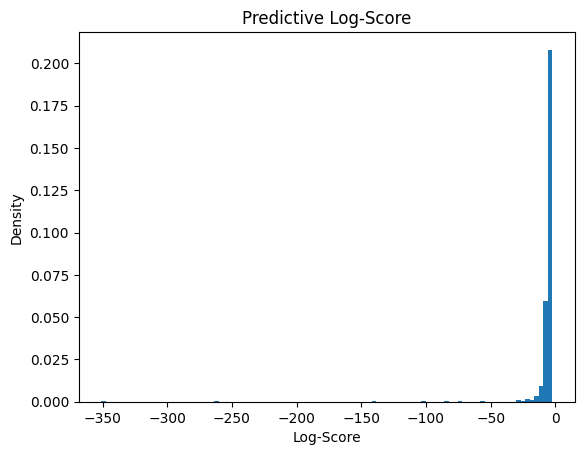

In [74]:
plt.hist(log_score, 100, density=True)
plt.title("Predictive Log-Score")
plt.ylabel("Density")
plt.xlabel("Log-Score")

In [75]:
p_waic = waic_from_loglik(obs_loglik_matrix)
print("p-WIAC", p_waic) # 103741.36731619679
print("log10 p-WIAC", np.log10(p_waic)) # 5.015951967717389

p-WIAC 103741.36731619679
log10 p-WIAC 5.015951967717389


In [ ]:
# k = [hour] + [day] + [fourier] + [mean trend] + [stochastic]
number_of_parameters = 23 + 6 + 6 + 2 + 2
loglik = logsumexp(obs_loglik_matrix, axis=0)

BIC = number_of_parameters * np.log(training_data.shape[0]-1) - 2 * max(loglik)
print("BIC:", BIC) # 369.40384175605577

BIC: 369.4038417560557


In [10]:
post_df.columns

Index(['draws', 'lp__', 'overall_mean', 'yearly_trend', 'theta', 'sigma',
       'day_coef_raw.1', 'day_coef_raw.2', 'day_coef_raw.3', 'day_coef_raw.4',
       'day_coef_raw.5', 'day_coef_raw.6', 'hour_coef_raw.1',
       'hour_coef_raw.2', 'hour_coef_raw.3', 'hour_coef_raw.4',
       'hour_coef_raw.5', 'hour_coef_raw.6', 'hour_coef_raw.7',
       'hour_coef_raw.8', 'hour_coef_raw.9', 'hour_coef_raw.10',
       'hour_coef_raw.11', 'hour_coef_raw.12', 'hour_coef_raw.13',
       'hour_coef_raw.14', 'hour_coef_raw.15', 'hour_coef_raw.16',
       'hour_coef_raw.17', 'hour_coef_raw.18', 'hour_coef_raw.19',
       'hour_coef_raw.20', 'hour_coef_raw.21', 'hour_coef_raw.22',
       'hour_coef_raw.23', 'fourier_coef.1.1', 'fourier_coef.1.2',
       'fourier_coef.1.3', 'fourier_coef.2.1', 'fourier_coef.2.2',
       'fourier_coef.2.3'],
      dtype='str')

In [ ]:
from arviz import ess
from arviz import rhat

post_ess_df = post_df.drop(columns=["draws", "lp__"])
post_ess_arr = post_ess_df.to_numpy()
post_ess_array = post_ess_arr.reshape(1000, 4, post_ess_arr.shape[1])

In [12]:
effective_sample_size = ess(post_ess_array, chain_axis=1, draw_axis=0)
print("EES:", min(effective_sample_size), max(effective_sample_size))

EES: 993.2620449264253 5678.811965850361


In [ ]:
effective_sample_size

In [15]:

post_ess_df.columns[effective_sample_size<2000] # hour_coefs

Index(['overall_mean', 'hour_coef_raw.2', 'hour_coef_raw.3', 'hour_coef_raw.4',
       'hour_coef_raw.5', 'hour_coef_raw.6', 'hour_coef_raw.7',
       'hour_coef_raw.8', 'hour_coef_raw.9', 'hour_coef_raw.10',
       'hour_coef_raw.11', 'hour_coef_raw.12', 'hour_coef_raw.13',
       'hour_coef_raw.14', 'hour_coef_raw.15', 'hour_coef_raw.16',
       'hour_coef_raw.17', 'hour_coef_raw.18', 'hour_coef_raw.19',
       'hour_coef_raw.20', 'hour_coef_raw.21', 'hour_coef_raw.22'],
      dtype='str')

In [16]:
effective_sample_size[effective_sample_size<2000]

array([1554.91575837, 1901.87742933, 1502.78455327, 1327.75587712,
       1212.61435289, 1120.54015067, 1222.06574249, 1207.90701122,
       1179.60423959, 1140.3608154 , 1165.8915711 , 1190.93500829,
       1093.55489105,  993.26204493, 1134.87072926, 1134.14735371,
       1173.9558305 , 1123.73864788, 1237.76552214, 1354.90668045,
       1495.89936576, 1762.48388405])

In [17]:
rhat(post_ess_array, chain_axis=1, draw_axis=0) < 1.05

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

# Blog Plots

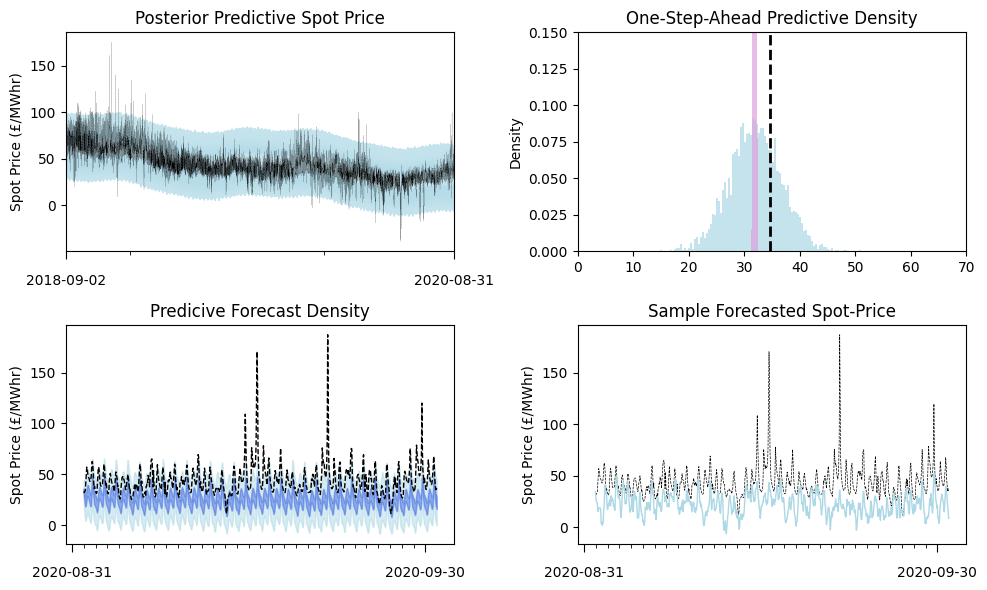

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(10,6), sharex=False)


axes[0,0].fill_between(training_data.index, 
                y_pred_qnts[0], 
                y_pred_qnts[3], 
                alpha=0.7, color='lightblue')
axes[0,0].plot(training_data.index, training_data['price_day_ahead_filled'], 
             color='black', linewidth=0.1, linestyle='--', alpha=1.0)
axes[0,0].set_title("Posterior Predictive Spot Price")
axes[0,0].set_ylabel("Spot Price (£/MWhr)")


# Show only the first and final day labels at their 00:00 observations
first_tick = training_data.index[0]
last_tick = training_data.index[-1]
first_day_tick = first_tick.normalize()
last_day_tick = last_tick.normalize()
intermediate_day_ticks = pd.date_range(
    start=first_day_tick + pd.Timedelta(days=1),
    end=last_day_tick - pd.Timedelta(days=1),
    freq='YE'
)

axes[0,0].set_xlim(first_tick, last_tick)
axes[0,0].set_xticks([first_day_tick, last_day_tick])
axes[0,0].set_xticklabels([
    first_day_tick.strftime("%Y-%m-%d"),
    last_day_tick.strftime("%Y-%m-%d")
])
axes[0,0].set_xticks(intermediate_day_ticks, minor=True)
axes[0,0].xaxis.set_minor_formatter(plt.NullFormatter())
axes[0,0].tick_params(axis="x", which="major", length=6, pad=10)
axes[0,0].tick_params(axis="x", which="minor", length=3, labelsize=8, pad=2)


axes[0,1].hist(one_step_pred[:,-1], 100, density=True, 
             color='lightblue', alpha=0.7, label="p()");
axes[0,1].hist(posterior_y_expected[:,-1], 100, density=True, 
             color='plum', alpha=0.7, label="E()");
axes[0,1].axvline(x=training_data['price_day_ahead_filled'].iloc[-1], 
            color='black', linestyle='--', linewidth=2, label="y")
axes[0,1].set_ylim([0, 0.15])
axes[0,1].set_xlim([0,70])
axes[0,1].set_ylabel("Density")
axes[0,1].set_title("One-Step-Ahead Predictive Density")

axes[1,0].fill_between(validation_X_data['time'], 
                pred_forecast_qnts[0], 
                pred_forecast_qnts[3], 
                alpha=0.5, color='lightblue', label="99% PI")
axes[1,0].fill_between(validation_X_data['time'], 
                pred_forecast_qnts[1], 
                pred_forecast_qnts[2], 
                alpha=0.5, color='royalblue', label="99% PI")
axes[1,0].plot(validation_data.index, validation_data['price_day_ahead_filled'], 
             color='black', linewidth=1.0, linestyle='--', alpha=1.0, label="Data")
axes[1,0].set_title("Predicive Forecast Density")
axes[1,0].set_ylabel("Spot Price (£/MWhr)")

first_tick = validation_X_data['time'].iloc[0]
last_tick = validation_X_data['time'].iloc[-1]
first_day_tick = first_tick.normalize()
last_day_tick = last_tick.normalize()
intermediate_day_ticks = pd.date_range(
    start=first_day_tick + pd.Timedelta(days=1),
    end=last_day_tick - pd.Timedelta(days=1),
    freq='D'
)

axes[1,0].set_xticks([first_day_tick, last_day_tick])
axes[1,0].set_xticklabels([
    first_day_tick.strftime("%Y-%m-%d"),
    last_day_tick.strftime("%Y-%m-%d")
])
axes[1,0].set_xticks(intermediate_day_ticks, minor=True)
axes[1,0].xaxis.set_minor_formatter(plt.NullFormatter())
axes[1,0].tick_params(axis="x", which="major", length=6, pad=10)
axes[1,0].tick_params(axis="x", which="minor", length=3, labelsize=8, pad=2)

axes[1,1].plot(validation_data.index, validation_data['price_day_ahead_filled'], 
             color='black', linewidth=0.5, linestyle='--', alpha=1.0, )
axes[1,1].plot(validation_X_data['time'], post_pred_validation[0], 
             color='lightblue', linewidth=1.0, linestyle='-', alpha=1.0,)
axes[1,1].set_title("Sample Forecasted Spot-Price")
axes[1,1].set_ylabel("Spot Price (£/MWhr)")

axes[1,1].set_xticks([first_day_tick, last_day_tick])
axes[1,1].set_xticklabels([
    first_day_tick.strftime("%Y-%m-%d"),
    last_day_tick.strftime("%Y-%m-%d")
])
axes[1,1].set_xticks(intermediate_day_ticks, minor=True)
axes[1,1].xaxis.set_minor_formatter(plt.NullFormatter())
axes[1,1].tick_params(axis="x", which="major", length=6, pad=10)
axes[1,1].tick_params(axis="x", which="minor", length=3, labelsize=8, pad=2)


plt.tight_layout()


In [ ]:
yearly_trend = posterior_mean_function_yearly_trend(post_df, training_X_data)
yearly_trend_qnts = np.quantile(yearly_trend, [0.005, 0.25, 0.75, 0.995], axis=0)

Text(0.5, 0, 'Time')

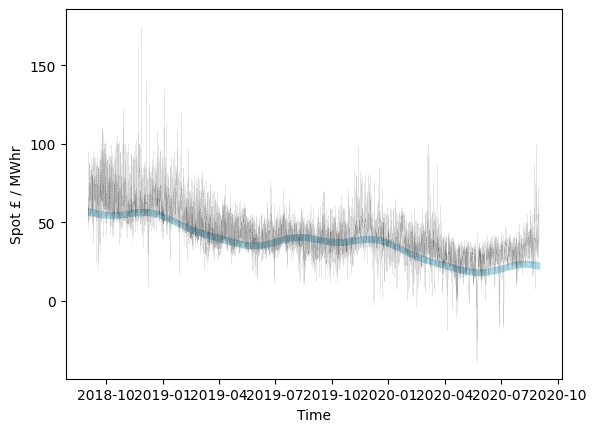

In [ ]:
plt.plot(training_data.index,
         training_data['GB_GBN_price_day_ahead'], 
         linestyle='--', color='black', linewidth=0.1, alpha=0.5, label="Data")
plt.fill_between(training_data.index, 
                 yearly_trend_qnts[0], 
                 yearly_trend_qnts[3], 
                 color='lightblue', alpha=1.0, label="99% PI")
plt.title("Posterior Mean Function")
plt.ylabel("Spot (£/MWhr)")
plt.xlabel("Time")